# CKAN — Convolutional KAN for MNIST
Train a **Convolutional Kolmogorov-Arnold Network** on MNIST and export the
learned B-spline functions as a `.mem` look-up table for the Verilog RTL.

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import numpy as np
import matplotlib.pyplot as plt
import math, os

try:
    from brevitas.nn import QuantIdentity
    from brevitas.core.scaling import ParameterScaling
    from brevitas.core.quant import QuantType
    BREVITAS_AVAILABLE = True
except ImportError:
    BREVITAS_AVAILABLE = False
    print('Warning: Brevitas not installed. Install with: pip install brevitas')

device = torch.device('cpu')
print(f'Using device: {device}')

Using device: cpu


## B-Spline Basis Functions
Compute order-*k* B-spline bases via the Cox-de Boor recursion.

In [2]:
def compute_bspline_basis(x, grid, k):
    """
    Compute B-spline basis functions of order k.

    Args:
        x    : (batch, in_features)  values in the grid range
        grid : (num_knots,)          shared knot vector
        k    : int                   spline order (degree)

    Returns:
        bases : (batch, in_features, grid_size + k)
    """
    x = x.unsqueeze(-1)                       # (B, F, 1)
    g = grid.unsqueeze(0).unsqueeze(0)         # (1, 1, num_knots)

    # Order 0: B_{i,0}(x) = 1 if grid[i] <= x < grid[i+1]
    bases = ((x >= g[:, :, :-1]) & (x < g[:, :, 1:])).to(x.dtype)

    # Cox-de Boor recursion for higher orders
    for p in range(1, k + 1):
        left  = (x - g[:, :, :-(p+1)]) / (g[:, :, p:-1] - g[:, :, :-(p+1)] + 1e-8)
        right = (g[:, :, (p+1):]  - x) / (g[:, :, (p+1):] - g[:, :, 1:(-p)]  + 1e-8)
        bases = left * bases[:, :, :-1] + right * bases[:, :, 1:]

    return bases

## KAN Linear Layer
Each weight is replaced by a learned B-spline univariate function plus a
residual SiLU path for training stability.

In [ ]:
class QuantBrevitasActivation(nn.Module):
    """Wrapper for Brevitas quantized activation."""
    def __init__(self, quant_identity, pre_transforms=None):
        super().__init__()
        self.quant_identity = quant_identity
        self.pre_transforms = pre_transforms or []
    
    def forward(self, x):
        return self.quant_identity(x)
    
    def get_state_space(self, is_cuda=False):
        """Return a representative state space for the quantizer."""
        return torch.linspace(self.quant_identity.min_val, 
                               self.quant_identity.max_val, 256)


class KANLinear(nn.Module):
    def __init__(self, in_features, out_features,
                 grid_size=5, spline_order=3, grid_range=(0.0, 1.0),
                 in_precision=8, out_precision=8, device=None):
        super().__init__()
        self.in_features  = in_features
        self.out_features = out_features
        self.grid_size    = grid_size
        self.spline_order = spline_order
        self.in_precision = in_precision
        self.out_precision = out_precision
        self.grid_range = grid_range
        self.device = device

        h = (grid_range[1] - grid_range[0]) / grid_size
        grid = torch.linspace(
            grid_range[0] - spline_order * h,
            grid_range[1] + spline_order * h,
            grid_size + 2 * spline_order + 1,
        )
        self.register_buffer('grid', grid)

        num_basis = grid_size + spline_order
        self.spline_weight = nn.Parameter(
            torch.randn(out_features, in_features, num_basis) * 0.1
        )
        self.base_weight = nn.Parameter(
            torch.randn(out_features, in_features) / math.sqrt(in_features)
        )
        
        # Spline selector for pruning
        self.spline_selector = nn.Parameter(torch.ones(out_features, in_features))
        self.spline_selector.requires_grad = False
        
        # Optional standalone spline scaler
        self.spline_scaler = nn.Parameter(torch.ones(out_features, in_features))
        
        # Output quantizer if Brevitas is available
        self.output_quantizer = None
        if BREVITAS_AVAILABLE:
            try:
                quant_identity = QuantIdentity(
                    bit_width=out_precision,
                    quant_type=QuantType.INT,
                    return_quant_tensor=False,
                    min_val=grid_range[0],
                    max_val=grid_range[1],
                    act_scaling_impl=ParameterScaling(1.33)
                )
                self.output_quantizer = QuantBrevitasActivation(quant_identity)
            except Exception as e:
                print(f'Warning: Could not initialize quantizer: {e}')

    def forward(self, x):
        # x: (batch, in_features)
        bases = compute_bspline_basis(x, self.grid, self.spline_order)
        
        # Spline output with learned scaling
        spline_out = torch.einsum('bfn,ofn->bo', bases, self.spline_weight * self.spline_scaler.unsqueeze(-1))
        
        # Base activation path
        base_out = F.linear(F.silu(x), self.base_weight)
        
        # Combine
        output = spline_out + base_out
        
        # Apply quantization if available
        if self.output_quantizer is not None:
            output = self.output_quantizer(output)
        
        return output
    
    @torch.no_grad()
    def prune_below_threshold(self, threshold: float = 0.01, 
                               next_layer_sparsity_matrix=None, 
                               input_state_space=None) -> None:
        """Prune spline weights below threshold."""
        if input_state_space is None:
            return
        
        x = input_state_space.unsqueeze(0).repeat(self.in_features, 1).T
        if self.device:
            x = x.to(self.device)
        
        bases = compute_bspline_basis(x, self.grid, self.spline_order)
        norms = torch.zeros((self.out_features, self.in_features))
        
        for out_idx in range(self.out_features):
            for in_idx in range(self.in_features):
                spline_out = F.linear(bases[:, in_idx, :], 
                                     self.spline_weight[out_idx, in_idx, :])
                norms[out_idx, in_idx] = self.spline_selector[out_idx, in_idx] * torch.norm(spline_out)
        
        self.spline_selector.data *= (norms > threshold).float()
        
        if next_layer_sparsity_matrix is not None:
            zero_cols = (next_layer_sparsity_matrix == 0).all(dim=0)
            self.spline_selector.data[zero_cols, :] = 0

## CKAN Convolution Layer
Uses `F.unfold` to extract patches, then applies `KANLinear` to each patch.

In [ ]:
class CKANConv2d(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size,
                 stride=1, padding=0, grid_size=5, spline_order=3,
                 in_precision=8, out_precision=8, device=None):
        super().__init__()
        self.in_channels  = in_channels
        self.out_channels = out_channels
        self.kernel_size  = kernel_size
        self.stride       = stride
        self.padding      = padding

        in_feat = in_channels * kernel_size * kernel_size
        self.kan = KANLinear(in_feat, out_channels, grid_size, spline_order,
                             in_precision=in_precision, 
                             out_precision=out_precision,
                             device=device)

    def forward(self, x):
        B, C, H, W = x.shape
        patches = F.unfold(x, self.kernel_size,
                           stride=self.stride, padding=self.padding)
        num_patches = patches.shape[2]
        patches = patches.permute(0, 2, 1).reshape(-1, patches.shape[1])

        out = self.kan(patches)                        # (B*P, Cout)
        out = out.reshape(B, num_patches, self.out_channels)
        out = out.permute(0, 2, 1)                     # (B, Cout, P)

        H_out = (H + 2*self.padding - self.kernel_size) // self.stride + 1
        W_out = (W + 2*self.padding - self.kernel_size) // self.stride + 1
        return out.reshape(B, self.out_channels, H_out, W_out)

## CKAN MNIST Model
One CKAN convolution layer followed by pooling and fully-connected layers.
The architecture matches the Verilog `Conv2D_KAN` module.

In [ ]:
class CKANMnist(nn.Module):
    def __init__(self, out_channels=8, kernel_size=3,
                 grid_size=5, spline_order=3, 
                 in_precision=8, out_precision=8, device=None):
        super().__init__()
        self.ckan_conv = CKANConv2d(
            in_channels=1, out_channels=out_channels,
            kernel_size=kernel_size, padding=0,
            grid_size=grid_size, spline_order=spline_order,
            in_precision=in_precision,
            out_precision=out_precision,
            device=device
        )
        # Output after conv (no padding): 28 - 3 + 1 = 26
        # After MaxPool(2): 13
        feat = out_channels * 13 * 13
        self.fc1 = nn.Linear(feat, 64)
        self.fc2 = nn.Linear(64, 10)

    def forward(self, x):
        x = self.ckan_conv(x)
        x = F.relu(x)
        x = F.max_pool2d(x, 2)
        x = x.flatten(1)
        x = F.relu(self.fc1(x))
        return self.fc2(x)

model = CKANMnist(out_channels=8, kernel_size=3,
                   grid_size=5, spline_order=3,
                   in_precision=8, out_precision=8,
                   device=device).to(device)
print(model)
total_params = sum(p.numel() for p in model.parameters())
print(f'Total parameters: {total_params:,}')
print(f'Quantization: Input {8}bit, Output {8}bit')

CKANMnist(
  (ckan_conv): CKANConv2d(
    (kan): KANLinear()
  )
  (fc1): Linear(in_features=1352, out_features=64, bias=True)
  (fc2): Linear(in_features=64, out_features=10, bias=True)
)
Total parameters: 87,890


## Dataset & Data Loaders

## Quantization & Pruning Support
The quantized KANLinear layer includes:
- **Output Quantization**: Learned spline functions quantized to 8-bit integers using Brevitas
- **Spline Scaler**: Per-output channel scaling for spline weights
- **Pruning**: Spline connection pruning via `spline_selector` based on L2 norm threshold
- **Backward Pruning**: Eliminates connections to pruned neurons in the next layer

In [ ]:
@torch.no_grad()
def apply_pruning(model, threshold=0.01):
    """
    Apply pruning to all KAN layers based on spline weight norms.
    
    Args:
        model: CKANMnist model
        threshold: Pruning threshold for L2 norms
    """
    layers = [model.ckan_conv.kan]
    
    for layer in layers:
        # Create input state space for pruning
        input_state_space = torch.linspace(layer.grid_range[0], 
                                           layer.grid_range[1], 256)
        
        # Apply pruning
        layer.prune_below_threshold(threshold, None, input_state_space)
        
        # Report sparsity
        sparsity = 1.0 - (layer.spline_selector.sum().item() / layer.spline_selector.numel())
        print(f'Layer sparsity: {100*sparsity:.1f}% ({int(layer.spline_selector.sum().item())} / {layer.spline_selector.numel()} connections active)')

# Example: Apply pruning (uncomment to use)
# apply_pruning(model, threshold=0.01)

## Quantization Configuration

In [ ]:
# Check quantization setup
print(f'Brevitas available: {BREVITAS_AVAILABLE}')
print(f'Model precision: {model.ckan_conv.kan.in_precision}bit input, {model.ckan_conv.kan.out_precision}bit output')
print(f'Output quantizer installed: {model.ckan_conv.kan.output_quantizer is not None}')
if model.ckan_conv.kan.output_quantizer is not None:
    quantizer_info = model.ckan_conv.kan.output_quantizer.quant_identity
    print(f'  - Quantizer range: [{quantizer_info.min_val}, {quantizer_info.max_val}]')
    print(f'  - Bit width: {quantizer_info.bit_width}')
    print(f'  - Type: {quantizer_info.quant_type}')

In [6]:
transform = transforms.Compose([
    transforms.ToTensor(),   # [0, 255] -> [0.0, 1.0]
])

train_ds = datasets.MNIST('./data', train=True,  download=True, transform=transform)
test_ds  = datasets.MNIST('./data', train=False, download=True, transform=transform)

BATCH_SIZE = 64
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False)
print(f'Train: {len(train_ds)}  Test: {len(test_ds)}')

100%|██████████| 9.91M/9.91M [00:03<00:00, 3.26MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 84.6kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 840kB/s] 
100%|██████████| 4.54k/4.54k [00:00<00:00, 8.83MB/s]

Train: 60000  Test: 10000


## Training Loop

In [ ]:
optimizer = optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()
EPOCHS = 5

def train_one_epoch(epoch):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for batch_idx, (data, target) in enumerate(train_loader):
        data, target = data.to(device), target.to(device)
        optimizer.zero_grad()
        output = model(data)
        loss = criterion(output, target)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * data.size(0)
        correct += output.argmax(1).eq(target).sum().item()
        total += data.size(0)

        if (batch_idx + 1) % 200 == 0:
            print(f'  Epoch {epoch} [{batch_idx+1}/{len(train_loader)}]  '
                  f'loss={running_loss/total:.4f}  acc={100*correct/total:.1f}%')
    return running_loss / total, correct / total

@torch.no_grad()
def evaluate():
    model.eval()
    correct, total = 0, 0
    for data, target in test_loader:
        data, target = data.to(device), target.to(device)
        output = model(data)
        correct += output.argmax(1).eq(target).sum().item()
        total += data.size(0)
    return correct / total

for epoch in range(1, EPOCHS + 1):
    train_loss, train_acc = train_one_epoch(epoch)
    test_acc = evaluate()
    print(f'Epoch {epoch}  train_loss={train_loss:.4f}  '
          f'train_acc={100*train_acc:.1f}%  test_acc={100*test_acc:.1f}%')

  Epoch 1 [200/938]  loss=0.5999  acc=83.2%
  Epoch 1 [400/938]  loss=0.4210  acc=88.1%
  Epoch 1 [600/938]  loss=0.3358  acc=90.3%
  Epoch 1 [800/938]  loss=0.2874  acc=91.7%
Epoch 1  train_loss=0.2640  train_acc=92.4%  test_acc=96.8%
  Epoch 2 [200/938]  loss=0.0927  acc=97.3%
  Epoch 2 [400/938]  loss=0.0908  acc=97.3%
  Epoch 2 [600/938]  loss=0.0895  acc=97.4%
  Epoch 2 [800/938]  loss=0.0866  acc=97.4%
Epoch 2  train_loss=0.0874  train_acc=97.4%  test_acc=97.5%
  Epoch 3 [200/938]  loss=0.0551  acc=98.3%
  Epoch 3 [400/938]  loss=0.0580  acc=98.2%
  Epoch 3 [600/938]  loss=0.0578  acc=98.2%
  Epoch 3 [800/938]  loss=0.0589  acc=98.2%
Epoch 3  train_loss=0.0592  train_acc=98.2%  test_acc=98.2%
  Epoch 4 [200/938]  loss=0.0408  acc=98.9%
  Epoch 4 [400/938]  loss=0.0419  acc=98.8%
  Epoch 4 [600/938]  loss=0.0447  acc=98.7%
  Epoch 4 [800/938]  loss=0.0438  acc=98.7%
Epoch 4  train_loss=0.0440  train_acc=98.7%  test_acc=98.0%
  Epoch 5 [200/938]  loss=0.0290  acc=99.1%
  Epoch 5 [4

## Visualise Learned KAN Functions
Plot a subset of the learned univariate functions (B-spline + SiLU residual).

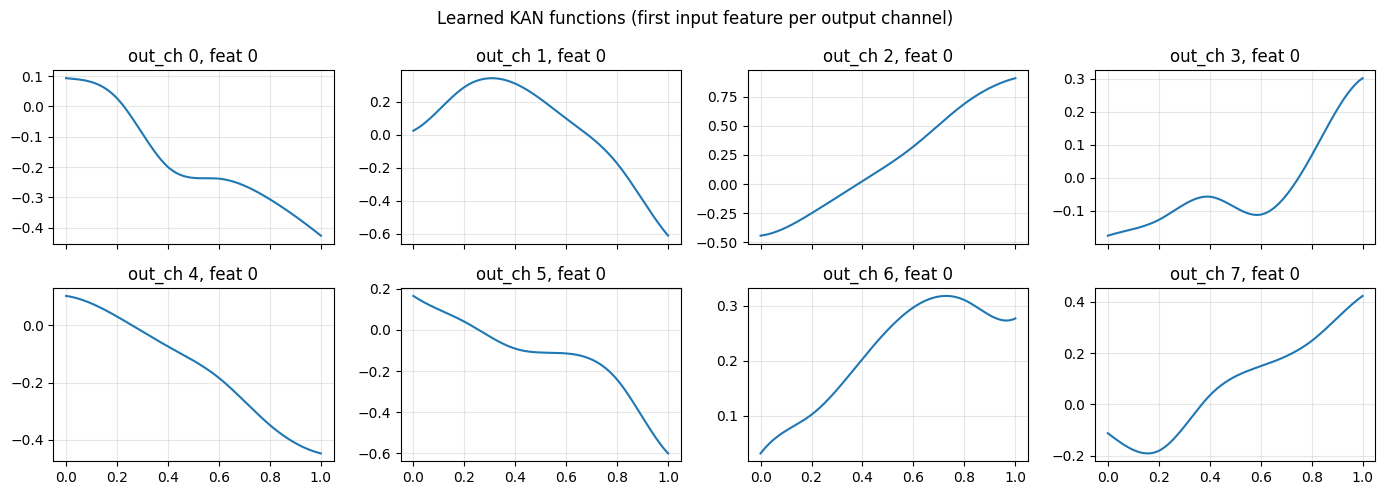

In [9]:
import matplotlib.pyplot as plt
@torch.no_grad()
def evaluate_kan_functions(model, num_points=256):
    """Return a (Cout, Cin*K*K, num_points) tensor of function values."""
    kan = model.ckan_conv.kan
    x_vals = torch.linspace(0, 1, num_points, device=kan.grid.device)
    x = x_vals.unsqueeze(1).expand(-1, kan.in_features)

    bases  = compute_bspline_basis(x, kan.grid, kan.spline_order)
    silu_x = F.silu(x)

    lut = torch.zeros(kan.out_features, kan.in_features, num_points)
    for o in range(kan.out_features):
        for f in range(kan.in_features):
            sp = (bases[:, f, :] * kan.spline_weight[o, f, :]).sum(dim=1)
            ba = kan.base_weight[o, f] * silu_x[:, f]
            lut[o, f, :] = sp + ba
    return lut, x_vals.cpu().numpy()

lut, x_axis = evaluate_kan_functions(model)

fig, axes = plt.subplots(2, 4, figsize=(14, 5), sharex=True)
fig.suptitle('Learned KAN functions (first input feature per output channel)')
for o in range(min(8, lut.shape[0])):
    ax = axes[o // 4, o % 4]
    ax.plot(x_axis, lut[o, 0, :].cpu().numpy())
    ax.set_title(f'out_ch {o}, feat 0')
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('kan_functions.png', dpi=150)
plt.show()

## Export B-Spline Functions to `.mem`
Evaluate every learned function at all 256 possible 8-bit input values,
quantise to `VALUE_WIDTH`-bit signed integers, and write the Verilog
`$readmemh`-compatible file.

### Address layout in the ROM
```
ROM[ {func_id, input_value} ]
```
Function ordering (matches the Verilog generate loops):
```
func = out_ch * (Cin * K * K) + in_ch * (K * K) + position
```

In [10]:
@torch.no_grad()
def export_to_mem(model, data_width=8, value_width=8,
                  filename='kan_lut_trained.mem'):
    """Export all learned KAN functions to a Verilog .mem file."""
    kan = model.ckan_conv.kan
    num_inputs   = 2 ** data_width
    out_features = kan.out_features
    in_features  = kan.in_features
    num_funcs    = out_features * in_features

    # Evaluate every function at every possible input value
    x_vals = torch.linspace(0, 1, num_inputs, device=kan.grid.device)
    x = x_vals.unsqueeze(1).expand(-1, in_features)
    bases  = compute_bspline_basis(x, kan.grid, kan.spline_order)
    silu_x = F.silu(x)

    lut = torch.zeros(out_features, in_features, num_inputs)
    for o in range(out_features):
        for f in range(in_features):
            sp = (bases[:, f, :] * kan.spline_weight[o, f, :]).sum(dim=1)
            ba = kan.base_weight[o, f] * silu_x[:, f]
            lut[o, f, :] = sp + ba

    # -- Symmetric quantisation --
    abs_max = lut.abs().max().item()
    if abs_max < 1e-8:
        abs_max = 1.0
    max_int = 2 ** (value_width - 1) - 1
    scale   = max_int / abs_max
    lut_q   = torch.clamp(torch.round(lut * scale), -max_int - 1, max_int).long()

    # -- Write .mem --
    hex_chars = (value_width + 3) // 4
    mask = (1 << value_width) - 1
    with open(filename, 'w') as f:
        f.write(f'// CKAN LUT  -  {num_funcs} functions x {num_inputs} entries\n')
        f.write(f'// Quantisation scale = {scale:.6f}\n')
        f.write(f'// Value width = {value_width} bits (signed)\n\n')

        for o in range(out_features):
            for feat in range(in_features):
                func_id = o * in_features + feat
                f.write(f'// func {func_id:3d}  out_ch={o} feat={feat}\n')
                for xi in range(num_inputs):
                    val = lut_q[o, feat, xi].item()
                    val_unsigned = val & mask
                    f.write(f'{val_unsigned:0{hex_chars}X}\n')

    print(f'Exported {num_funcs} functions x {num_inputs} entries to {filename}')
    print(f'Quantisation scale: {scale:.6f}')
    print(f'LUT value range: [{lut.min().item():.4f}, {lut.max().item():.4f}]')
    return lut_q

lut_q = export_to_mem(model, data_width=8, value_width=8,
                      filename='kan_lut_trained.mem')

Exported 72 functions x 256 entries to kan_lut_trained.mem
Quantisation scale: 124.455014
LUT value range: [-1.0204, 0.9758]


## Quick Sanity Check

In [12]:
# Show first few lines of the generated .mem file
with open('kan_lut_trained.mem') as f:
    for i, line in enumerate(f):
        print(line, end='')
        if i >= 20:
            print('...')
            break

// CKAN LUT  -  72 functions x 256 entries
// Quantisation scale = 124.455014
// Value width = 8 bits (signed)

// func   0  out_ch=0 feat=0
0C
0C
0B
0B
0B
0B
0B
0B
0B
0B
0B
0B
0B
0B
0B
0B
...


## Using the `.mem` with the Verilog Model
Copy `kan_lut_trained.mem` alongside the Verilog sources and instantiate
`Conv2D_KAN` with matching parameters:

```verilog
Conv2D_KAN #(
    .KERNEL_SIZE     (3),
    .COLUMN_NUM      (28),
    .ROW_NUM         (28),
    .STRIDE          (1),
    .INPUT_CHANNELS  (1),
    .OUTPUT_CHANNELS (8),
    .DATA_WIDTH      (8),
    .VALUE_WIDTH     (8),
    .OUT_WIDTH       (16)
) ckan_inst ( ... );
```

Update `KAN_LUT_ROM` to point to the new file:
```verilog
parameter MEM_FILE = "kan_lut_trained.mem"
```